In [ ]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

In [18]:
def leer_dosis_phits_tdeposit(filename):
    posicion = []
    dosis = []
    error_relativo = []
    leyendo_tabla = False
    eje = None

    with open(filename, "r", encoding="utf-8", errors="ignore") as archivo:
        for linea in archivo:
            texto = linea.strip()

            if texto.startswith("#  z-lower") and "proton" in texto:
                eje = "z"
                leyendo_tabla = True
                continue

            if texto.startswith("#  r-lower") and "proton" in texto:
                eje = "r"
                leyendo_tabla = True
                continue

            if leyendo_tabla:
                partes = texto.replace("D", "E").split()

                if len(partes) != 4:
                    if dosis:
                        break
                    continue

                try:
                    limite_inferior = float(partes[0])
                    limite_superior = float(partes[1])
                    dosis_proton = float(partes[2])
                    error = float(partes[3])
                except ValueError:
                    if dosis:
                        break
                    continue

                posicion.append((limite_inferior + limite_superior) / 2)
                dosis.append(dosis_proton)
                error_relativo.append(error)

    return (
        np.array(posicion),
        np.array(dosis),
        np.array(error_relativo),
        eje
    )

In [19]:
carpeta_out = Path("../out")
file_path = carpeta_out / "bragg_pouch_z.out"

z, data_dosis, error_relativo, eje = leer_dosis_phits_tdeposit(file_path)

print("Cantidad de valores:", len(data_dosis))
print("Primeras posiciones:", z[:5])
print("Primeras dosis:", data_dosis[:5])

Cantidad de valores: 200
Primeras posiciones: [97.005 97.015 97.025 97.035 97.045]
Primeras dosis: [0.23388 0.2344  0.23341 0.23298 0.23231]


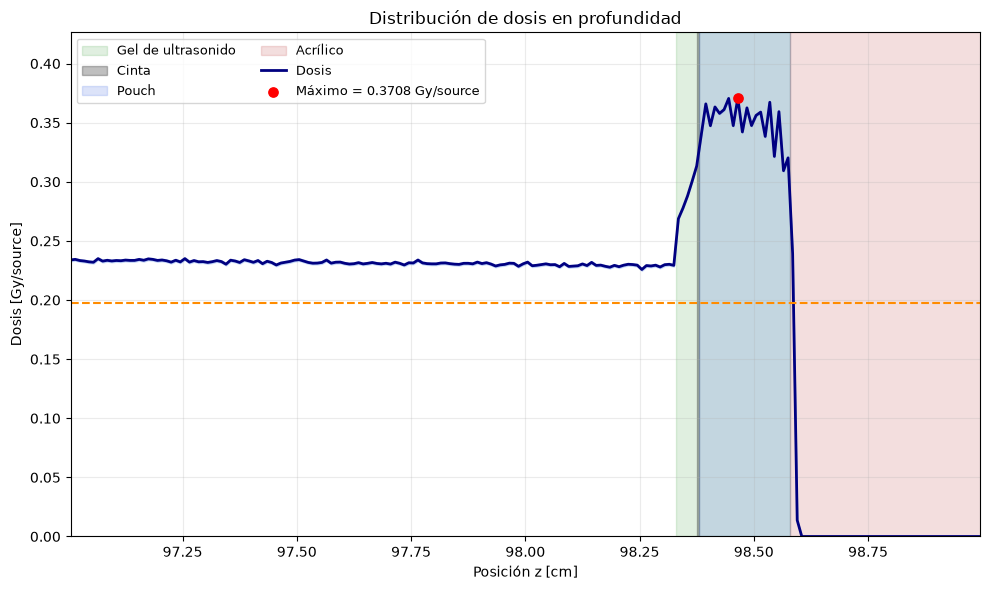

Dosis mínima: 0.000000 Gy/source
Dosis máxima: 0.370790 Gy/source
Posición del máximo: 98.4650 cm
Dosis media: 0.197412 Gy/source
Error relativo medio: 0.79 %


In [20]:
error_absoluto = data_dosis * error_relativo
dosis_media = np.mean(data_dosis)
dosis_maxima = np.max(data_dosis)
z_maximo = z[np.argmax(data_dosis)]

fig, ax = plt.subplots(figsize=(10, 6))

ax.axvspan(98.33, 98.58, color="green", alpha=0.12, label="Gel de ultrasonido")
ax.axvspan(98.375, 98.38, color="black", alpha=0.25, label="Cinta")
ax.axvspan(98.38, 98.58, color="royalblue", alpha=0.18, label="Pouch")
ax.axvspan(98.58, 99.01, color="firebrick", alpha=0.15, label="Acrílico")

ax.plot(
    z,
    data_dosis,
    color="navy",
    linewidth=2,
    label="Dosis"
)

ax.fill_between(
    z,
    data_dosis - error_absoluto,
    data_dosis + error_absoluto,
    color="cornflowerblue",
    alpha=0.3
)

ax.axhline(
    dosis_media,
    color="darkorange",
    linestyle="--",
    linewidth=1.5
)

ax.scatter(
    z_maximo,
    dosis_maxima,
    color="red",
    s=45,
    zorder=5,
    label=f"Máximo = {dosis_maxima:.4f} Gy/source"
)

ax.set_xlim(z.min(), z.max())
ax.set_ylim(0, dosis_maxima * 1.15)

ax.set_xlabel("Posición z [cm]")
ax.set_ylabel("Dosis [Gy/source]")
ax.set_title("Distribución de dosis en profundidad")

ax.grid(True, alpha=0.25)
ax.legend(fontsize=9, ncols=2)
fig.tight_layout()

plt.show()

print(f"Dosis mínima: {data_dosis.min():.6f} Gy/source")
print(f"Dosis máxima: {dosis_maxima:.6f} Gy/source")
print(f"Posición del máximo: {z_maximo:.4f} cm")
print(f"Dosis media: {dosis_media:.6f} Gy/source")
print(f"Error relativo medio: {100*np.mean(error_relativo):.2f} %")

### Le aplicamos un suavizado

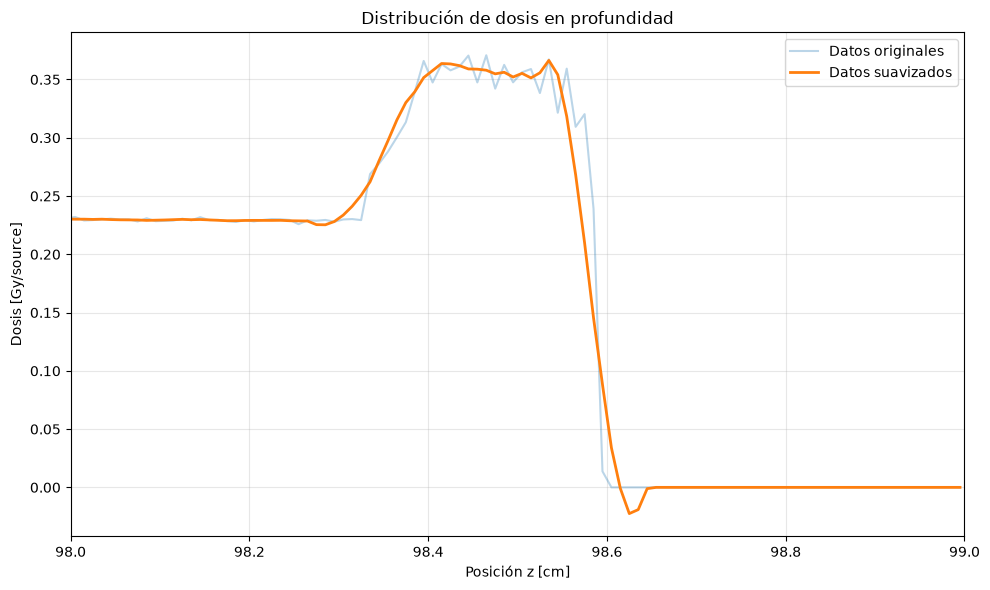

In [29]:
from scipy.signal import savgol_filter

dosis_suavizada = savgol_filter(data_dosis, 12, 3)

plt.figure(figsize=(10, 6))
plt.plot(z, data_dosis, alpha=0.3, label="Datos originales")
plt.plot(z, dosis_suavizada, linewidth=2, label="Datos suavizados")
plt.xlim(98, 99)

plt.xlabel("Posición z [cm]")
plt.ylabel("Dosis [Gy/source]")
plt.title("Distribución de dosis en profundidad")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

### Dosis Radial

In [22]:
file_path_r = carpeta_out / "bragg_pouch_r.out"

r, dosis_radial, error_relativo_r, eje = leer_dosis_phits_tdeposit(file_path_r)

print("Eje leído:", eje)
print("Cantidad de valores:", len(dosis_radial))
print("Primeros radios:", r[:5])
print("Primeras dosis:", dosis_radial[:5])

Eje leído: r
Cantidad de valores: 60
Primeros radios: [0.0141665 0.0425    0.0708335 0.099165  0.1275   ]
Primeras dosis: [0.36046 0.34892 0.35186 0.34818 0.34194]


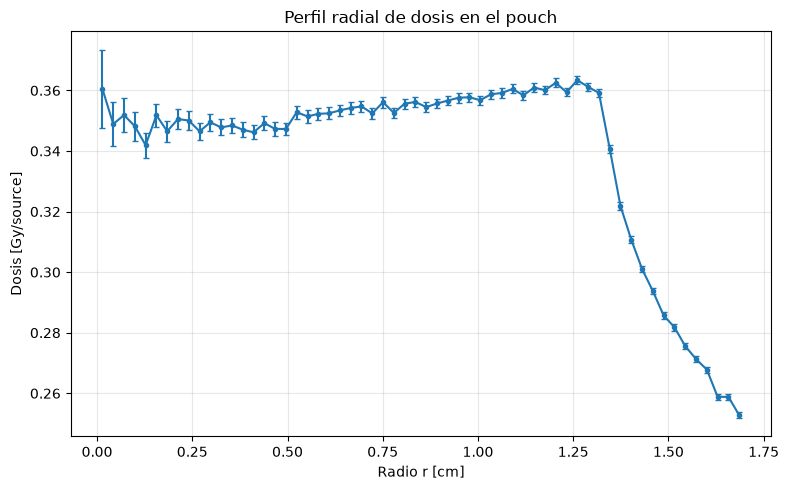

In [23]:
error_absoluto_r = dosis_radial * error_relativo_r

plt.figure(figsize=(8, 5))

plt.errorbar(
    r,
    dosis_radial,
    yerr=error_absoluto_r,
    fmt="o-",
    markersize=3,
    capsize=2
)

plt.xlabel("Radio r [cm]")
plt.ylabel("Dosis [Gy/source]")
plt.title("Perfil radial de dosis en el pouch")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [24]:
dosis_minima = np.min(dosis_radial)
dosis_maxima = np.max(dosis_radial)
dosis_media = np.mean(dosis_radial)
mediana = np.median(dosis_radial)
desvio = np.std(dosis_radial)
cv = 100 * desvio / dosis_media

r_minimo = r[np.argmin(dosis_radial)]
r_maximo = r[np.argmax(dosis_radial)]

print(f"Dosis mínima: {dosis_minima:.6f} Gy/source")
print(f"Posición del mínimo: {r_minimo:.4f} cm")
print(f"Dosis máxima: {dosis_maxima:.6f} Gy/source")
print(f"Posición del máximo: {r_maximo:.4f} cm")
print(f"Dosis media: {dosis_media:.6f} Gy/source")
print(f"Mediana: {mediana:.6f} Gy/source")
print(f"Desviación estándar: {desvio:.6f} Gy/source")
print(f"Coeficiente de variación: {cv:.2f} %")
print(f"Error relativo medio: {100*np.mean(error_relativo_r):.2f} %")

Dosis mínima: 0.252780 Gy/source
Posición del mínimo: 1.6858 cm
Dosis máxima: 0.363400 Gy/source
Posición del máximo: 1.2609 cm
Dosis media: 0.339118 Gy/source
Mediana: 0.351830 Gy/source
Desviación estándar: 0.030585 Gy/source
Coeficiente de variación: 9.02 %
Error relativo medio: 0.64 %
